### Demand Forecasting
**E-Commerce Demand Forecasting & Supply Chain Optimization**

Models compared:
- SARIMA — Seasonal AutoRegressive Integrated Moving Average
- ETS    — Exponential Smoothing (Holt-Winters)
- Prophet — Meta's time series forecasting library
- XGBoost — Gradient boosting with engineered time features

Evaluation: RMSE, MAE, MAPE with rolling cross-validation

In [1]:
# Cell 1 — Imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import warnings
warnings.filterwarnings('ignore')

# Forecasting
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.holtwinters import ExponentialSmoothing
from statsmodels.tsa.stattools import adfuller
from prophet import Prophet
from xgboost import XGBRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error
from sklearn.model_selection import TimeSeriesSplit
import mlflow
import mlflow.sklearn

plt.rcParams['figure.figsize'] = (14, 5)
print('Libraries loaded')

Libraries loaded


In [2]:
# Cell 2 — Load Processed Data
demand = pd.read_csv('../data/processed/demand_clean.csv', parse_dates=['date'])
print('Demand shape:', demand.shape)
demand.head(3)

Demand shape: (913000, 9)


,date,store,item,sales,year,month,dow,week,quarter
0,2013-01-01,1,1,13,2013,1,1,1,1
1,2013-01-02,1,1,11,2013,1,2,1,1
2,2013-01-03,1,1,14,2013,1,3,1,1


In [3]:
# Cell 3 — Aggregate: Total Daily Sales Across All Stores & Items
daily = demand.groupby('date')['sales'].sum().reset_index()
daily.columns = ['date', 'sales']
daily = daily.sort_values('date').reset_index(drop=True)

# Train / Test split — last 90 days as test
split_date = daily['date'].max() - pd.Timedelta(days=90)
train = daily[daily['date'] <= split_date].copy()
test  = daily[daily['date'] >  split_date].copy()

print(f'Train size : {len(train)} days ({train["date"].min().date()} → {train["date"].max().date()})')
print(f'Test size  : {len(test)} days  ({test["date"].min().date()} → {test["date"].max().date()})')

Train size : 1736 days (2013-01-01 → 2017-10-02)
Test size  : 90 days  (2017-10-03 → 2017-12-31)


In [4]:
# Cell 4 — Stationarity Check (ADF Test)
result = adfuller(train['sales'])
print('=== Augmented Dickey-Fuller Test ===')
print(f'ADF Statistic : {result[0]:.4f}')
print(f'P-value       : {result[1]:.4f}')
print(f'Critical (5%) : {result[4]["5%"]:.4f}')
print()
if result[1] < 0.05:
    print('Series is STATIONARY — ready for SARIMA')
else:
    print('Series is NON-STATIONARY — differencing needed (d=1)')

=== Augmented Dickey-Fuller Test ===
ADF Statistic : -2.8911
P-value       : 0.0464
Critical (5%) : -2.8632

Series is STATIONARY — ready for SARIMA


In [5]:
# Cell 5 — Helper: Evaluation Metrics
def evaluate(actual, predicted, model_name):
    rmse = np.sqrt(mean_squared_error(actual, predicted))
    mae  = mean_absolute_error(actual, predicted)
    mape = np.mean(np.abs((actual - predicted) / actual)) * 100
    print(f'--- {model_name} ---')
    print(f'  RMSE : {rmse:.2f}')
    print(f'  MAE  : {mae:.2f}')
    print(f'  MAPE : {mape:.2f}%')
    return {'model': model_name, 'RMSE': round(rmse,2), 'MAE': round(mae,2), 'MAPE': round(mape,2)}

results = []
print('Evaluation function ready')

Evaluation function ready


In [6]:
# Cell 6 — Model 1: SARIMA
print('Training SARIMA...')

sarima_model = SARIMAX(
    train['sales'],
    order=(1, 1, 1),
    seasonal_order=(1, 1, 1, 7),  # weekly seasonality
    enforce_stationarity=False,
    enforce_invertibility=False
)
sarima_fit    = sarima_model.fit(disp=False)
sarima_pred   = sarima_fit.forecast(steps=len(test))
sarima_pred   = np.maximum(sarima_pred, 0)  # no negative sales

res_sarima = evaluate(test['sales'].values, sarima_pred, 'SARIMA')
results.append(res_sarima)
print('\nSARIMA done')

Training SARIMA...
--- SARIMA ---
  RMSE : 3070.82
  MAE  : 2522.64
  MAPE : 9.22%

SARIMA done


In [7]:
# Cell 7 — Model 2: ETS (Holt-Winters Exponential Smoothing)
print('Training ETS...')

ets_model = ExponentialSmoothing(
    train['sales'],
    trend='add',
    seasonal='add',
    seasonal_periods=7
)
ets_fit  = ets_model.fit(optimized=True)
ets_pred = ets_fit.forecast(steps=len(test))
ets_pred = np.maximum(ets_pred, 0)

res_ets = evaluate(test['sales'].values, ets_pred, 'ETS')
results.append(res_ets)
print('\nETS done')

Training ETS...
--- ETS ---
  RMSE : 4422.99
  MAE  : 3194.00
  MAPE : 13.41%

ETS done


In [8]:
# Cell 8 — Model 3: Prophet
print('Training Prophet...')

prophet_train = train.rename(columns={'date': 'ds', 'sales': 'y'})
prophet_test  = test.rename(columns={'date': 'ds', 'sales': 'y'})

prophet_model = Prophet(
    yearly_seasonality=True,
    weekly_seasonality=True,
    daily_seasonality=False,
    changepoint_prior_scale=0.05
)
prophet_model.fit(prophet_train)

future       = prophet_model.make_future_dataframe(periods=len(test))
forecast     = prophet_model.predict(future)
prophet_pred = forecast.tail(len(test))['yhat'].values
prophet_pred = np.maximum(prophet_pred, 0)

res_prophet = evaluate(test['sales'].values, prophet_pred, 'Prophet')
results.append(res_prophet)
print('\nProphet done')

Training Prophet...


20:11:17 - cmdstanpy - INFO - Chain [1] start processing
20:11:17 - cmdstanpy - INFO - Chain [1] done processing


--- Prophet ---
  RMSE : 1522.42
  MAE  : 1111.45
  MAPE : 4.25%

Prophet done


In [9]:
# Cell 9 — Model 4: XGBoost with Time Features
print('Training XGBoost...')

def make_features(df):
    df = df.copy()
    df['dayofweek']  = df['date'].dt.dayofweek
    df['month']      = df['date'].dt.month
    df['quarter']    = df['date'].dt.quarter
    df['year']       = df['date'].dt.year
    df['dayofyear']  = df['date'].dt.dayofyear
    df['weekofyear'] = df['date'].dt.isocalendar().week.astype(int)
    df['lag_7']      = df['sales'].shift(7)
    df['lag_14']     = df['sales'].shift(14)
    df['lag_30']     = df['sales'].shift(30)
    df['roll_7']     = df['sales'].shift(1).rolling(7).mean()
    df['roll_30']    = df['sales'].shift(1).rolling(30).mean()
    return df

full_df  = make_features(daily)
features = ['dayofweek','month','quarter','year','dayofyear','weekofyear',
            'lag_7','lag_14','lag_30','roll_7','roll_30']

full_clean = full_df.dropna(subset=features)
xgb_train  = full_clean[full_clean['date'] <= split_date]
xgb_test   = full_clean[full_clean['date'] >  split_date]

xgb_model = XGBRegressor(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=4,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)
xgb_model.fit(xgb_train[features], xgb_train['sales'],
              eval_set=[(xgb_test[features], xgb_test['sales'])],
              verbose=False)

xgb_pred = xgb_model.predict(xgb_test[features])
xgb_pred = np.maximum(xgb_pred, 0)

res_xgb = evaluate(xgb_test['sales'].values, xgb_pred, 'XGBoost')
results.append(res_xgb)
print('\nXGBoost done')

Training XGBoost...
--- XGBoost ---
  RMSE : 895.95
  MAE  : 526.31
  MAPE : 1.99%

XGBoost done


In [10]:
# Cell 10 — Model Comparison Table
results_df = pd.DataFrame(results).sort_values('RMSE')
print('=== Model Comparison ===')
display(results_df)

best_model = results_df.iloc[0]['model']
best_rmse  = results_df.iloc[0]['RMSE']
worst_rmse = results_df.iloc[-1]['RMSE']
improvement = round((worst_rmse - best_rmse) / worst_rmse * 100, 1)

print(f'\n🏆 Best model  : {best_model} (RMSE: {best_rmse})')
print(f'📈 Improvement : {improvement}% over worst model')

=== Model Comparison ===


,model,RMSE,MAE,MAPE
3,XGBoost,895.95,526.31,1.99
2,Prophet,1522.42,1111.45,4.25
0,SARIMA,3070.82,2522.64,9.22
1,ETS,4422.99,3194.00,13.41



🏆 Best model  : XGBoost (RMSE: 895.95)
📈 Improvement : 79.7% over worst model


In [11]:
# Cell 11 — Forecast vs Actual Plot (All Models)
fig = go.Figure()

fig.add_trace(go.Scatter(x=test['date'], y=test['sales'],
                          name='Actual', line=dict(color='#1a1a2e', width=2.5)))
fig.add_trace(go.Scatter(x=test['date'], y=sarima_pred,
                          name='SARIMA', line=dict(color='#e74c3c', width=1.8, dash='dot')))
fig.add_trace(go.Scatter(x=test['date'], y=ets_pred,
                          name='ETS', line=dict(color='#f39c12', width=1.8, dash='dash')))
fig.add_trace(go.Scatter(x=test['date'], y=prophet_pred,
                          name='Prophet', line=dict(color='#9b59b6', width=1.8)))
fig.add_trace(go.Scatter(x=xgb_test['date'], y=xgb_pred,
                          name='XGBoost', line=dict(color='#1a936f', width=1.8)))

fig.update_layout(
    title='Forecast vs Actual — All Models (Test Set: 90 Days)',
    xaxis_title='Date', yaxis_title='Sales',
    height=480, plot_bgcolor='white', paper_bgcolor='white',
    xaxis=dict(showgrid=False), yaxis=dict(gridcolor='#f0f0f0'),
    legend=dict(orientation='h', y=-0.2)
)
fig.show()

In [12]:
# Cell 12 — Model Comparison Bar Chart
fig = px.bar(results_df, x='model', y='RMSE',
             title='RMSE Comparison — All Models (Lower is Better)',
             color='RMSE', color_continuous_scale='RdYlGn_r',
             text='RMSE')
fig.update_traces(textposition='outside')
fig.update_layout(height=400, plot_bgcolor='white', paper_bgcolor='white',
                  xaxis=dict(showgrid=False), yaxis=dict(showticklabels=False))
fig.show()

fig2 = px.bar(results_df, x='model', y='MAPE',
              title='MAPE Comparison — All Models (Lower is Better)',
              color='MAPE', color_continuous_scale='RdYlGn_r',
              text='MAPE')
fig2.update_traces(texttemplate='%{text:.2f}%', textposition='outside')
fig2.update_layout(height=400, plot_bgcolor='white', paper_bgcolor='white',
                   xaxis=dict(showgrid=False), yaxis=dict(showticklabels=False))
fig2.show()

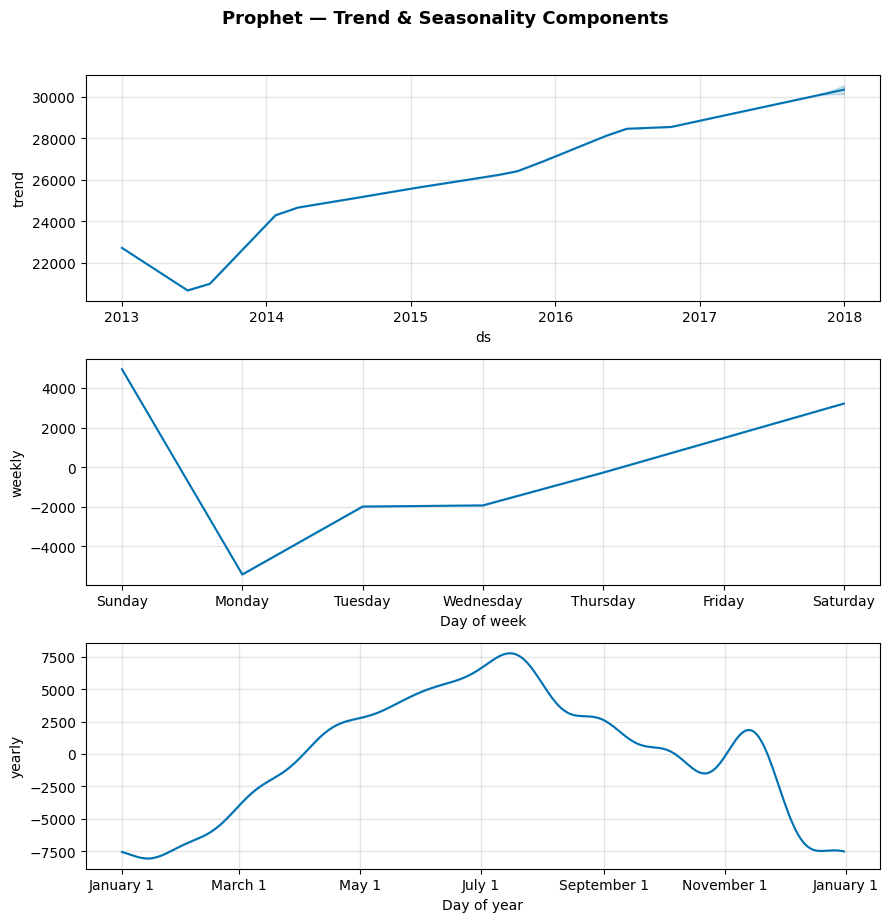

In [13]:
# Cell 13 — Prophet Components (Trend + Seasonality)
fig_comp = prophet_model.plot_components(forecast)
plt.suptitle('Prophet — Trend & Seasonality Components', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

In [14]:
# Cell 14 — XGBoost Feature Importance
feat_imp = pd.DataFrame({
    'feature':   features,
    'importance': xgb_model.feature_importances_
}).sort_values('importance', ascending=True)

fig = px.bar(feat_imp, x='importance', y='feature', orientation='h',
             title='XGBoost — Feature Importance',
             color='importance', color_continuous_scale='Greens',
             text='importance')
fig.update_traces(texttemplate='%{text:.3f}', textposition='outside')
fig.update_layout(height=420, plot_bgcolor='white', paper_bgcolor='white',
                  xaxis=dict(showgrid=False, showticklabels=False), yaxis_title='')
fig.show()

In [15]:
# Cell 15 — Rolling Cross Validation (XGBoost)
print('Running rolling cross-validation...')

tscv      = TimeSeriesSplit(n_splits=5)
cv_scores = []
X = full_clean[features].values
y = full_clean['sales'].values

for fold, (tr_idx, val_idx) in enumerate(tscv.split(X)):
    X_tr, X_val = X[tr_idx], X[val_idx]
    y_tr, y_val = y[tr_idx], y[val_idx]

    m = XGBRegressor(n_estimators=300, learning_rate=0.05,
                     max_depth=4, random_state=42)
    m.fit(X_tr, y_tr, verbose=False)
    preds = m.predict(X_val)
    rmse  = np.sqrt(mean_squared_error(y_val, preds))
    cv_scores.append(rmse)
    print(f'  Fold {fold+1} RMSE: {rmse:.2f}')

print(f'\nMean CV RMSE : {np.mean(cv_scores):.2f}')
print(f'Std  CV RMSE : {np.std(cv_scores):.2f}')

Running rolling cross-validation...
  Fold 1 RMSE: 1975.70
  Fold 2 RMSE: 1223.11
  Fold 3 RMSE: 815.48
  Fold 4 RMSE: 1149.90
  Fold 5 RMSE: 912.93

Mean CV RMSE : 1215.42
Std  CV RMSE : 408.37


In [16]:
# Cell 16 — Log to MLflow
import mlflow
import mlflow.sklearn
import os

# Set MLflow to always log to project root
project_root = os.path.abspath(os.path.join(os.getcwd(), '..'))
mlflow.set_tracking_uri(f"file://{project_root}/mlruns")
mlflow.set_experiment('ecommerce_forecasting')

for res in results:
    with mlflow.start_run(run_name=res['model']):
        mlflow.log_param('model',    res['model'])
        mlflow.log_metric('RMSE',    res['RMSE'])
        mlflow.log_metric('MAE',     res['MAE'])
        mlflow.log_metric('MAPE',    res['MAPE'])

with mlflow.start_run(run_name='XGBoost_final'):
    mlflow.log_param('n_estimators',    500)
    mlflow.log_param('learning_rate',   0.05)
    mlflow.log_param('max_depth',       4)
    mlflow.log_metric('RMSE',           res_xgb['RMSE'])
    mlflow.log_metric('MAE',            res_xgb['MAE'])
    mlflow.log_metric('MAPE',           res_xgb['MAPE'])
    mlflow.log_metric('cv_mean_rmse',   round(np.mean(cv_scores), 2))
    mlflow.sklearn.log_model(xgb_model, 'xgboost_model')

print('✅ All runs logged to MLflow')
print(f'   Tracking URI: {mlflow.get_tracking_uri()}')
print('   Run: mlflow ui   to view dashboard')

2026/03/09 20:11:20 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/03/09 20:11:22 WARNING mlflow.models.model: Model logged without a signature and input example. Please set `input_example` parameter when logging the model to auto infer the model signature.


✅ All runs logged to MLflow
   Tracking URI: file:///Users/chaitanyasura/Downloads/GIT_Projects/ecommerce-forecast/mlruns
   Run: mlflow ui   to view dashboard


In [17]:
# Cell 17 — Save Results
import os
os.makedirs('../data/processed', exist_ok=True)

results_df.to_csv('../data/processed/model_comparison.csv', index=False)

# Save best predictions for supply chain notebook
test_out = test.copy()
test_out['sarima_pred']  = sarima_pred
test_out['ets_pred']     = ets_pred
test_out['prophet_pred'] = prophet_pred

xgb_out = xgb_test[['date','sales']].copy()
xgb_out['xgb_pred'] = xgb_pred
forecast_out = test_out.merge(xgb_out[['date','xgb_pred']], on='date', how='left')
forecast_out.to_csv('../data/processed/forecast_results.csv', index=False)

print('✅ model_comparison.csv saved')
print('✅ forecast_results.csv saved')
print()
print('=== Final Summary ===')
display(results_df)
print(f'\n🏆 Best model     : {best_model}')
print(f'📉 Best RMSE      : {best_rmse}')
print(f'📊 CV Mean RMSE   : {np.mean(cv_scores):.2f} ± {np.std(cv_scores):.2f}')

✅ model_comparison.csv saved
✅ forecast_results.csv saved

=== Final Summary ===


,model,RMSE,MAE,MAPE
3,XGBoost,895.95,526.31,1.99
2,Prophet,1522.42,1111.45,4.25
0,SARIMA,3070.82,2522.64,9.22
1,ETS,4422.99,3194.00,13.41



🏆 Best model     : XGBoost
📉 Best RMSE      : 895.95
📊 CV Mean RMSE   : 1215.42 ± 408.37
